In [1]:
# =========================
# 1. IMPORTS
# =========================

import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

In [2]:
# =========================
# 2. PATHS + DEVICE
# =========================

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SPLIT_DIR = BASE_DIR / "data" / "splits"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Base directory:", BASE_DIR)
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Base directory: D:\Git\eshani-2026\e_wardrobe_ai
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# =========================
# 3. LOAD SPLIT DATA
# =========================

train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print("Before filtering")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Before filtering
Train: (24266, 11)
Validation: (5200, 11)
Test: (5201, 11)


In [4]:
# =========================
# 4. FILTER COLOR CLASSES
# =========================

target_col = "baseColour"
MIN_SAMPLES = 200

valid_classes = train_df[target_col].value_counts()
valid_classes = valid_classes[valid_classes >= MIN_SAMPLES].index

train_df = train_df[train_df[target_col].isin(valid_classes)].copy()
val_df = val_df[val_df[target_col].isin(valid_classes)].copy()
test_df = test_df[test_df[target_col].isin(valid_classes)].copy()

print("After filtering")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Number of color classes:", train_df[target_col].nunique())

train_df[target_col].value_counts()

After filtering
Train: (22772, 11)
Validation: (4891, 11)
Test: (4903, 11)
Number of color classes: 17


baseColour
Black        5642
White        3350
Blue         2758
Brown        2120
Grey         1534
Red          1298
Green        1168
Navy Blue     992
Pink          845
Purple        822
Yellow        440
Beige         419
Silver        383
Orange        292
Maroon        263
Gold          226
Olive         220
Name: count, dtype: int64

In [5]:
# =========================
# 5. CREATE LABEL MAPPING
# =========================

classes = sorted(train_df[target_col].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

num_classes = len(classes)

print("Number of classes:", num_classes)
print(class_to_idx)

with open(MODEL_DIR / "color_class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=4)

Number of classes: 17
{'Beige': 0, 'Black': 1, 'Blue': 2, 'Brown': 3, 'Gold': 4, 'Green': 5, 'Grey': 6, 'Maroon': 7, 'Navy Blue': 8, 'Olive': 9, 'Orange': 10, 'Pink': 11, 'Purple': 12, 'Red': 13, 'Silver': 14, 'White': 15, 'Yellow': 16}


In [6]:
# =========================
# 6. IMAGE TRANSFORMS
# =========================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# =========================
# 7. DATASET CLASS
# =========================

class WardrobeDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, target_col, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_path = row["image_path"]
        label_name = row[self.target_col]
        label = self.class_to_idx[label_name]

        try:
            image = Image.open(image_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (224, 224), color=(255, 255, 255))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [8]:
# =========================
# 8. DATASETS + DATALOADERS
# =========================

BATCH_SIZE = 32

train_dataset = WardrobeDataset(
    train_df,
    class_to_idx,
    target_col,
    transform=train_transform
)

val_dataset = WardrobeDataset(
    val_df,
    class_to_idx,
    target_col,
    transform=eval_transform
)

test_dataset = WardrobeDataset(
    test_df,
    class_to_idx,
    target_col,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 712
Validation batches: 153
Test batches: 154


In [9]:
# =========================
# 9. BUILD MOBILENETV2 MODEL
# =========================

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

print("Color model ready.")

Color model ready.


In [10]:
# =========================
# 10. LOSS + OPTIMIZER
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [11]:
# =========================
# 11. TRAIN FUNCTION
# =========================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
# =========================
# 12. VALIDATION FUNCTION
# =========================

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
# =========================
# 13. TRAIN MODEL
# =========================

EPOCHS = 5
best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = MODEL_DIR / "mobilenetv2_color_best.pth"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best color model saved.")

print("\nTraining completed.")
print("Best validation accuracy:", best_val_acc)
print("Model saved to:", best_model_path)


Epoch 1/5
----------------------------------------


100%|████████████████████████████████████████| 153/153 [00:23<00:00,  6.57it/s]


Train Loss: 1.2583 | Train Acc: 0.6154
Val Loss:   0.8550 | Val Acc:   0.7258
Best color model saved.

Epoch 2/5
----------------------------------------


100%|████████████████████████████████████████| 153/153 [00:17<00:00,  8.61it/s]


Train Loss: 0.8850 | Train Acc: 0.7125
Val Loss:   0.7809 | Val Acc:   0.7401
Best color model saved.

Epoch 3/5
----------------------------------------


...

Train Loss: 0.7970 | Train Acc: 0.7373
Val Loss:   0.7490 | Val Acc:   0.7467
Best color model saved.

Epoch 4/5
----------------------------------------


100%|████████████████████████████████████████| 153/153 [00:18<00:00,  8.30it/s]


Train Loss: 0.7366 | Train Acc: 0.7568
Val Loss:   0.7366 | Val Acc:   0.7567
Best color model saved.

Epoch 5/5
----------------------------------------


100%|████████████████████████████████████████| 153/153 [00:17<00:00,  8.57it/s]

Train Loss: 0.6893 | Train Acc: 0.7692
Val Loss:   0.7341 | Val Acc:   0.7506

Training completed.
Best validation accuracy: 0.7566959721938253
Model saved to: D:\Git\eshani-2026\e_wardrobe_ai\models\mobilenetv2_color_best.pth


In [14]:
# =========================
# 14. SAVE TRAINING HISTORY
# =========================

history_path = MODEL_DIR / "mobilenetv2_color_training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved to:", history_path)

Training history saved to: D:\Git\eshani-2026\e_wardrobe_ai\models\mobilenetv2_color_training_history.json


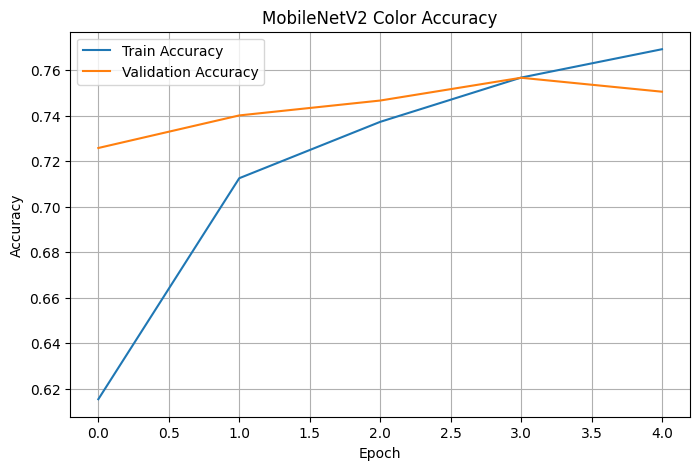

In [15]:
# =========================
# 15. PLOT ACCURACY
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("MobileNetV2 Color Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

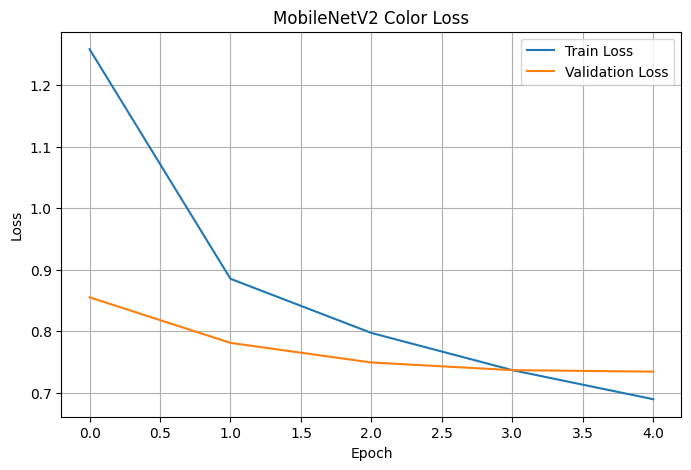

In [16]:
# =========================
# 16. PLOT LOSS
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Color Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()